In [40]:
import math
import numpy as np
import matplotlib.pyplot as plt

In [41]:
# Initial Setup

# 収束誤差
error_max = 0.001
# 
coff = 1.75
# 
p_a = 1.0

In [42]:
rr = 3.0
zz = 6.0
lambda_coff = 10.0
eps = 0.1

nx = 60
nz = 80

dx = 2.0 * math.pi /nx
dz = zz / rr / nz
dx5 = 0.5 * dx
dz5 = 0.5 * dz

In [43]:
a =  np.zeros((2,3))
a[0][1]

np.float64(0.0)

In [44]:
aaN = np.zeros((nx,nz+1))
aaS = np.zeros((nx,nz+1))
aaE = np.zeros((nx,nz+1))
aaW = np.zeros((nx,nz+1))
aaO = np.zeros((nx,nz+1))
bbO = np.zeros((nx,nz+1))

for iz in range(nz):
    for ix in range(nx-1):
        xx0 = ix * dx
        xp1 = xx0 + dx5
        xm1 = xx0 - dx5

        hhn=  1.0 + eps*math.cos(xx0)

        hhs = 1.0 + eps*math.cos(xx0)
        hhe = 1.0 + eps*math.cos(xp1)
        hhw = 1.0 + eps*math.cos(xm1)

        aaN[ix][iz] = (dx/dz) * hhn**3
        aaS[ix][iz] = (dx/dz) * hhs**3
        aaE[ix][iz] = (dx/dz) * hhe**3
        aaW[ix][iz] = (dx/dz) * hhw**3
        aaO[ix][iz] = aaN[ix][iz] + aaS[ix][iz] + aaE[ix][iz] + aaW[ix][iz]
        bbO[ix][iz] = lambda_coff * dz * (hhw - hhe)

In [45]:
pp = np.zeros((nx,nz))

for iz in range(nx-1):
    for iz in range(nx):
        pp[ix][iz]= p_a

In [46]:
count = 0
error = 1.0

while error > error_max:
    error = 0.0
    for ix in range(nx-1):
        ixp = ix + 1
        ixm = ix - 1
        if ix == 0:
            ixm = nx - 1
        if ix == nx - 1:
            ixp = 0
        for iz in range(nz-1):
            izp = iz + 1
            izm = iz - 1

            ddd = (aaN[ix][iz]*pp[ix][izp] + aaS[ix][iz]*pp[ix][izm] + aaE[ix][iz]*pp[ixp][iz] + aaW[ix][iz]*pp[ixm][iz] + bbO[ix][iz]) / aaO[ix][iz] - pp[ix][iz]

            error = error + abs(ddd)
            pp[ix][iz] = pp[ix][iz] + coff * ddd
    
    count += 1
    if count % 100 == 0:
        print(count)
        print(error)

100
0.07893524040660574
200
0.011675065808885705
300
0.001810265417815713


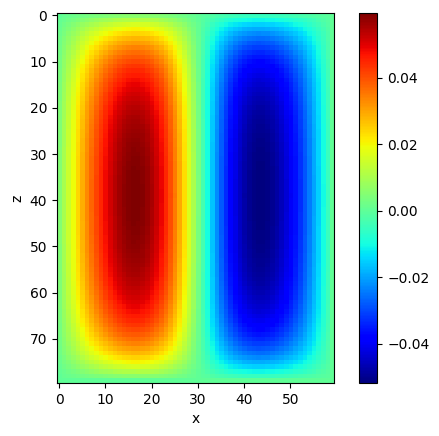

In [47]:
im = plt.imshow(pp.T, cmap='jet')
plt.colorbar(im)
plt.xlabel('x')
plt.ylabel('z')
plt.show()